<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/owenabbata-hw3/2026/HW/OwenAbbata/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 3 - Elevator Pressure

In this experiment I measured the change in the air pressure as I rode up the Clements Hall elevator (10 stories). The only challenge I faced was getting an undisturbed elevator ride, I solved this problem by going to Clements Hall at 9am on a tuesday 30 minutes before the classes usally start.

In [18]:
import numpy as np
import pandas as pa
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

,Time (s),Pressure (hPa)
0,-0.521728,1003.513565
1,0.509464,1003.512115
2,1.540633,1003.510590
3,2.571816,1003.509979
4,3.603021,1003.509979
5,3.797478,1003.509979
6,4.861865,1003.508682
7,5.926309,1003.507385
8,6.990772,1003.504944
9,8.055247,1003.495560


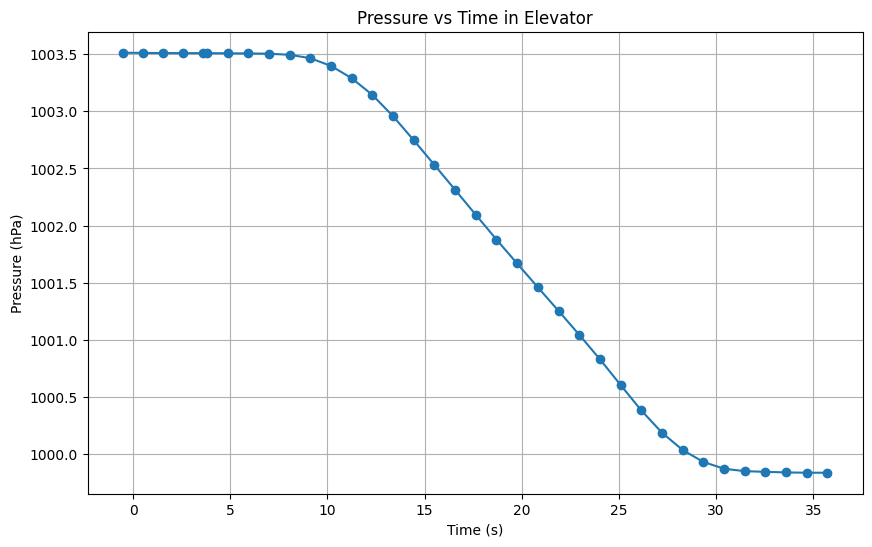

In [42]:
# Loading data
df = pa.read_csv('https://raw.githubusercontent.com/ubsuny/PHY386/refs/heads/owenabbata-hw3/2026/HW/OwenAbbata/Owenabbata_HW3_Data.csv')

# Display first 10 rows
display(df.head(10))

# Create a plot of Time (s) vs Pressure (hPa) using the DataFrame
plt.figure(figsize=(10, 6))
plt.plot(df['Time (s)'], df['Pressure (hPa)'], marker='o', linestyle='-')
plt.title('Pressure vs Time in Elevator')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (hPa)')
plt.grid(True)
plt.show()

In [20]:
# Check for missing values
df.isnull().sum()


,0
Time (s),0
Pressure (hPa),0


In [21]:
# Calculate the time differences between consecutive readings
time_diffs = df['Time (s)'].diff()

# Display the first 10 time differences
print("First 10 time differences (s):")
display(time_diffs.head(10))

# Display descriptive statistics of the time differences
print("\nDescriptive statistics of time differences (s):")
display(time_diffs.describe())

First 10 time differences (s):


,Time (s)
0,NaN
1,1.031192
2,1.031169
3,1.031183
4,1.031205
5,0.194457
6,1.064387
7,1.064444
8,1.064463
9,1.064475



Descriptive statistics of time differences (s):


,Time (s)
count,35.000000
mean,1.035783
std,0.146784
min,0.194457
25%,1.064404
50%,1.064441
75%,1.064460
max,1.064480


In [28]:
# Cut the DataFrame so it doesn't have the data where the elevator wasn't running
# We cut off the first 10.5 seconds and anything after 26.5 seconds because that is when the elevator was not moving
df_cut = df[(df['Time (s)'] > 10.5) & (df['Time (s)'] < 26.5)]


In [29]:
# Get descriptive statistics for the cut DataFrame
df_descriptive = df_cut.describe()

# Print mean, std, min, and max for Time (s) and Pressure (hPa)
print("Descriptive statistics for df_cut:")
display(df_descriptive.loc[['mean', 'std', 'min', 'max']])

Descriptive statistics for df_cut:


,Time (s),Pressure (hPa)
mean,18.699800,1001.880213
std,4.760325,0.942939
min,11.248641,1000.382233
max,26.150806,1003.291016


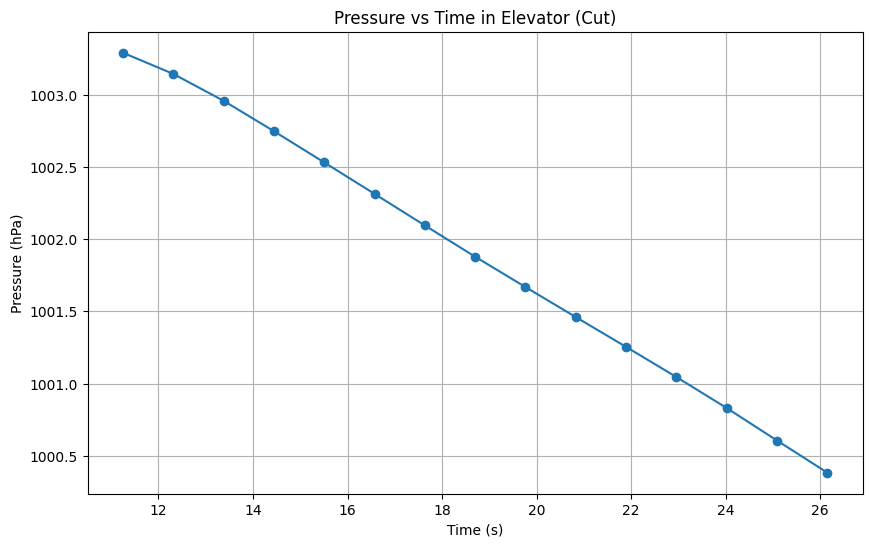

In [43]:
# Create a plot of Time (s) vs Pressure (hPa) using the cut DataFrame
plt.figure(figsize=(10, 6))
plt.plot(df_cut['Time (s)'], df_cut['Pressure (hPa)'], marker='o', linestyle='-')
plt.title('Pressure vs Time in Elevator (Cut)')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (hPa)')
plt.grid(True)
plt.show()

In [50]:
# Calculate uncertainty (standard deviation) for Pressure and Time from the cut DataFrame
pressure_uncertainty = df_cut['Pressure (hPa)'].std()
time_uncertainty = df_cut['Time (s)'].std()

print(f"Uncertainty in Pressure (hPa): {pressure_uncertainty:.4f}")
print(f"Uncertainty in Time (s): {time_uncertainty:.4f}")

Uncertainty in Pressure (hPa): 0.9429
Uncertainty in Time (s): 4.7603


In [48]:
# Define elevator speed
elevator_speed = 1  # m/s

# Calculate height using h = v * t
df_cut['Height (m)'] = df_cut['Time (s)'] * elevator_speed

# Display the DataFrame with the new 'Height (m)' column
display(df_cut)

,Time (s),Pressure (hPa),Height (m)
12,11.248641,1003.291016,11.248641
13,12.313115,1003.144531,12.313115
14,13.377561,1002.958298,13.377561
15,14.442020,1002.747879,14.442020
16,15.506479,1002.531509,15.506479
17,16.570931,1002.313461,16.570931
18,17.635410,1002.094955,17.635410
19,18.699873,1001.878128,18.699873
20,19.764347,1001.668091,19.764347
21,20.828770,1001.460037,20.828770


In [52]:
# Calculate uncertainty in Height (m)
# Assuming elevator_speed (v) is constant and its uncertainty is negligible.
# The uncertainty in height (dH) = v * dTime, where dTime is time_uncertainty.
height_uncertainty = elevator_speed * time_uncertainty

print(f"Uncertainty in Height (m): {height_uncertainty:.4f}")

Uncertainty in Height (m): 4.7603


In [55]:
H = 8500.0 # Scale height in meters

def barometric_model(height, P0):
    """Calculates pressure using the barometric formula."""
    return P0 * np.exp(-height / H)

In [56]:
x_data = df_cut['Height (m)']
y_data = df_cut['Pressure (hPa)']

# Initial guess for P0: the initial pressure value
p0_initial_guess = y_data.iloc[0]

# Fit the curve using curve_fit
popt, pcov = curve_fit(barometric_model, x_data, y_data, p0=[p0_initial_guess])

print(f"Optimal parameter P0: {popt[0]:.4f}")

Optimal parameter P0: 1004.0868
